# CS111 Project Template — 2D Heat Equation with the FFT

We solve the periodic 2D heat equation

$$u_t = \kappa (u_{xx} + u_{yy}), \qquad (x,y) \in [0,2\pi]^2$$

with periodic boundary conditions.

This notebook is a guided project template. The main idea is to solve the PDE in **Fourier space**, where the Laplacian becomes diagonal.


## From finite differences to Fourier methods

In finite differences, we approximate derivatives locally on a grid.

In Fourier methods, we represent the solution as a sum of global modes:

$$u(x,y,t) = \sum_{k,\ell} \hat u_{k,\ell}(t)e^{i(kx+\ell y)}.$$

These modes are eigenfunctions of the Laplacian:

$$\Delta e^{i(kx+\ell y)} = -(k^2+\ell^2)e^{i(kx+\ell y)}.$$

So the PDE becomes many independent scalar ODEs in Fourier space.


## Big picture of the algorithm

We will:

1. define a 2D periodic initial condition
2. compute its 2D FFT
3. build the 2D wave number arrays
4. evolve each Fourier mode exactly in time
5. inverse FFT back to physical space
6. visualize diffusion and spectral decay

The key scientific computing idea is:

> choose a basis that diagonalizes the operator.


## Step 0 — Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Step 1 — Heat equation in Fourier space

Start with

$$u_t = \kappa (u_{xx}+u_{yy}).$$

Write

$$u(x,y,t)=\sum_{k,\ell} \hat u_{k,\ell}(t)e^{i(kx+\ell y)}.$$ 

Since

$$\Delta e^{i(kx+\ell y)} = -(k^2+\ell^2)e^{i(kx+\ell y)},$$

each Fourier coefficient satisfies

$$\frac{d\hat u_{k,\ell}}{dt} = -\kappa (k^2+\ell^2) \hat u_{k,\ell}.$$ 

So the exact mode-by-mode solution is

$$\hat u_{k,\ell}(t) = e^{-\kappa (k^2+\ell^2)t} \hat u_{k,\ell}(0).$$

This is the formula we implement.


## Step 2 — Set up the 2D periodic grid

We work on $[0,2\pi)\times[0,2\pi)$ using a periodic grid.


In [2]:
Lx = 2.0 * np.pi
Ly = 2.0 * np.pi
nx = 128
ny = 128

x = np.linspace(0.0, Lx, nx, endpoint=False)
y = np.linspace(0.0, Ly, ny, endpoint=False)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing='xy')
kappa = 0.08

print('Grid:', nx, 'x', ny)
print('dx =', dx)
print('dy =', dy)


Grid: 128 x 128
dx = 0.04908738521234052
dy = 0.04908738521234052


## Step 3 — Define the initial condition

A good project-sized initial condition should have structure in both space directions.

This example combines a few smooth Fourier-like patterns with a localized hot spot.


In [3]:
def initial_condition(X, Y):
    return (
        0.8 * np.sin(X)
        + 0.5 * np.cos(2 * Y)
        + 0.3 * np.sin(3 * X - 2 * Y)
        + 0.8 * np.exp(-6.0 * ((X - np.pi)**2 + (Y - np.pi)**2))
    )


u0 = initial_condition(X, Y)


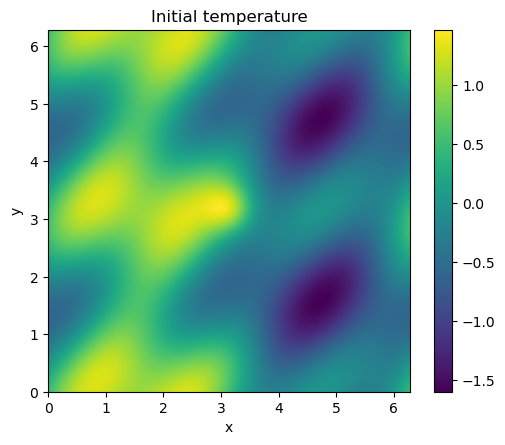

In [4]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(u0, origin='lower', extent=[0, Lx, 0, Ly])
plt.title('Initial temperature')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 4 — Compute the 2D FFT

The 2D FFT gives the Fourier coefficients $\hat u_{k,\ell}(0)$ of the sampled initial condition.

We use `numpy.fft.fft2` and `numpy.fft.ifft2` as computational tools.


In [5]:
u0_hat = np.fft.fft2(u0)
print('Shape of Fourier coefficient array:', u0_hat.shape)


Shape of Fourier coefficient array: (128, 128)


## Step 5 — Build the wave number arrays

For the Fourier-space formula

$$\hat u_{k,\ell}(t) = e^{-\kappa (k^2+\ell^2)t}\hat u_{k,\ell}(0),$$

we need the wave numbers in both directions.


In [6]:
kx = 2.0 * np.pi * np.fft.fftfreq(nx, d=dx)
ky = 2.0 * np.pi * np.fft.fftfreq(ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='xy')
K2 = KX**2 + KY**2

print('K2 shape:', K2.shape)


K2 shape: (128, 128)


## Step 6 — Evolve the solution in Fourier space

Given time `t`, we evolve every Fourier mode exactly:

$$\hat u_{k,\ell}(t) = e^{-\kappa (k^2+\ell^2)t}\hat u_{k,\ell}(0).$$

Then we inverse FFT back to physical space.


In [7]:
def heat_solution_fft_2d(u0, K2, kappa, t):
    """Return the 2D heat equation solution at time t using the FFT."""
    u0_hat = np.fft.fft2(u0)
    decay = np.exp(-kappa * K2 * t)
    u_hat_t = decay * u0_hat
    u_t = np.fft.ifft2(u_hat_t)
    return np.real(u_t)


## Step 7 — Plot the solution at several times

This should show the 2D temperature field smoothing over time.


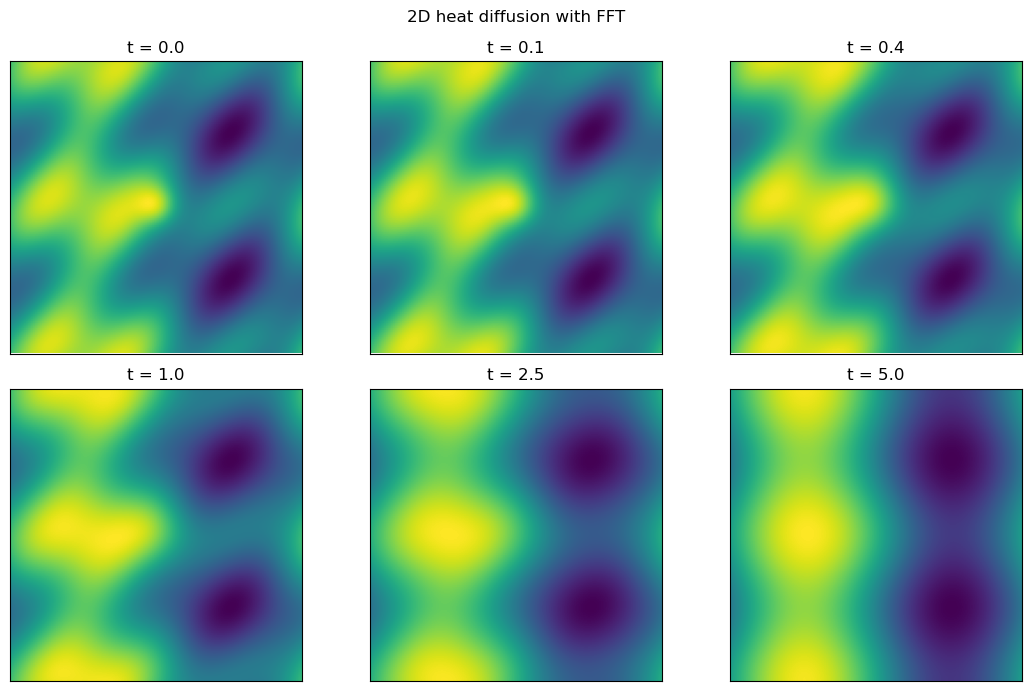

In [8]:
times = [0.0, 0.1, 0.4, 1.0, 2.5, 5.0]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.ravel()

for ax, t in zip(axes, times):
    ut = heat_solution_fft_2d(u0, K2, kappa, t)
    im = ax.imshow(ut, origin='lower', extent=[0, Lx, 0, Ly])
    ax.set_title(f't = {t}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('2D heat diffusion with FFT')
plt.tight_layout()
plt.show()


## Step 8 — Compare initial and final temperature fields

This makes the smoothing effect easier to see.


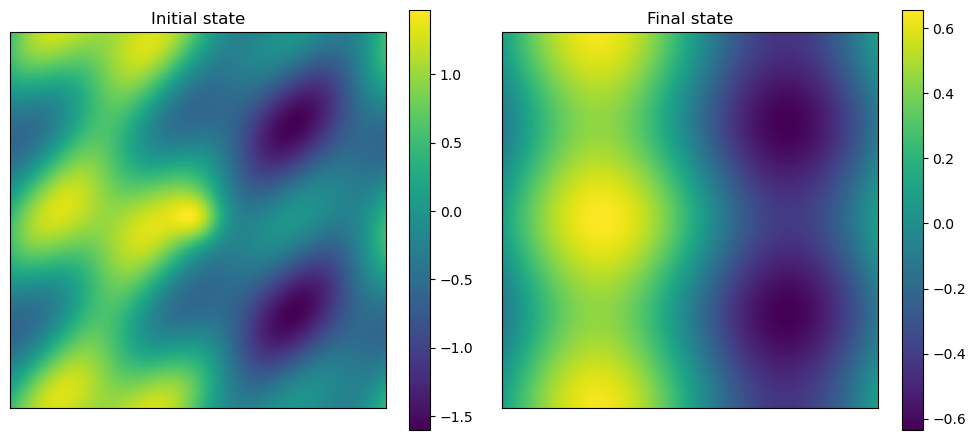

In [9]:
u_final = heat_solution_fft_2d(u0, K2, kappa, 5.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

im0 = axes[0].imshow(u0, origin='lower', extent=[0, Lx, 0, Ly])
axes[0].set_title('Initial state')
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_final, origin='lower', extent=[0, Lx, 0, Ly])
axes[1].set_title('Final state')
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


## Step 9 — Why does diffusion smooth?

Every Fourier mode is multiplied by

$$e^{-\kappa (k^2+\ell^2)t}.$$ 

So modes with large $k^2+\ell^2$ decay quickly.

That means high-frequency spatial structure disappears first.


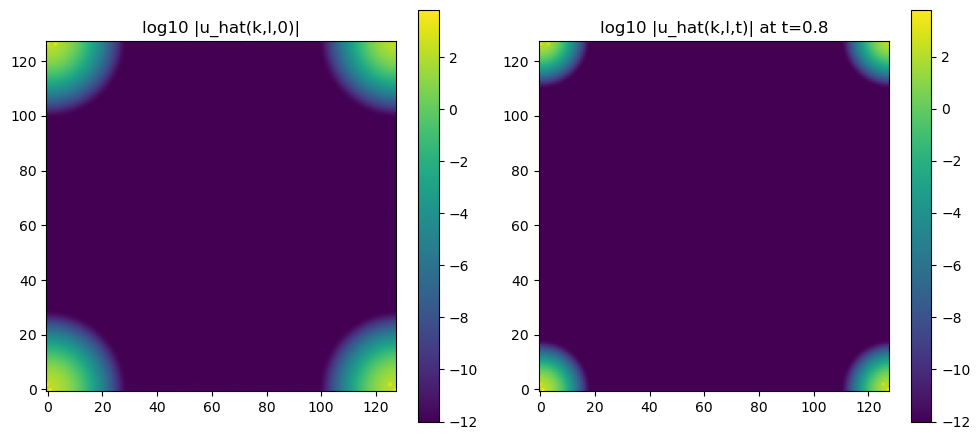

In [10]:
t = 0.8
mode_strength_0 = np.abs(u0_hat)
mode_strength_t = np.abs(np.exp(-kappa * K2 * t) * u0_hat)

plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
plt.imshow(np.log10(mode_strength_0 + 1e-12), origin='lower')
plt.title('log10 |u_hat(k,l,0)|')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(np.log10(mode_strength_t + 1e-12), origin='lower')
plt.title(f'log10 |u_hat(k,l,t)| at t={t}')
plt.colorbar()

plt.tight_layout()
plt.show()


## Step 10 — Radial spectral decay view

A simpler way to see the same effect is to inspect the decay factor

$$e^{-\kappa (k^2+\ell^2)t}.$$ 

This depends only on the squared wave number magnitude.


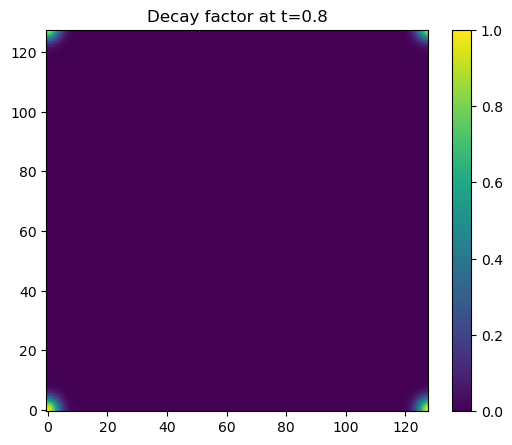

In [11]:
t = 0.8
decay = np.exp(-kappa * K2 * t)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(decay, origin='lower')
plt.title(f'Decay factor at t={t}')
plt.colorbar()
plt.tight_layout()
plt.show()


## Step 11 — Time sequence for project-style visualization

This produces a longer sequence of snapshots. It can be used as a basis for an animation or for selecting frames in a report.


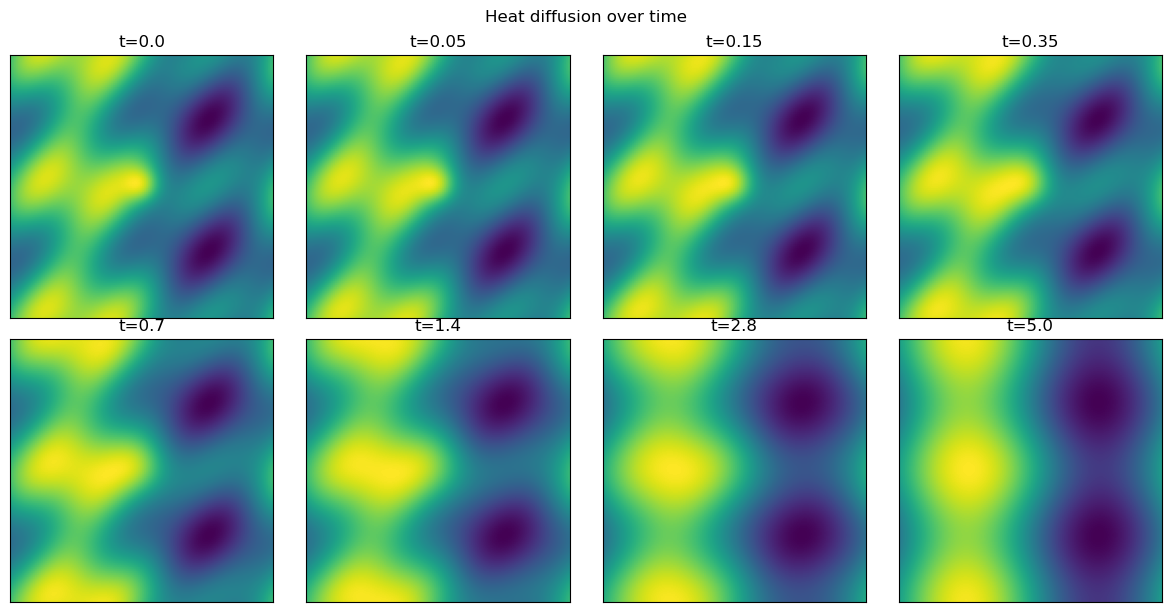

In [12]:
time_grid = [0.0, 0.05, 0.15, 0.35, 0.7, 1.4, 2.8, 5.0]

fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
axes = axes.ravel()

for ax, t in zip(axes, time_grid):
    ut = heat_solution_fft_2d(u0, K2, kappa, t)
    ax.imshow(ut, origin='lower', extent=[0, Lx, 0, Ly])
    ax.set_title(f't={t}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Heat diffusion over time')
plt.tight_layout()
plt.show()


## Step 12 — Single Fourier mode check

If the initial condition is exactly one Fourier mode,

$$u(x,y,0)=\sin(mx)\cos(\ell y),$$

then the exact solution is

$$u(x,y,t)=e^{-\kappa(m^2+\ell^2)t}\sin(mx)\cos(\ell y).$$

This gives a clean correctness check.


RMS error for single-mode test: 9.732104040570401e-17


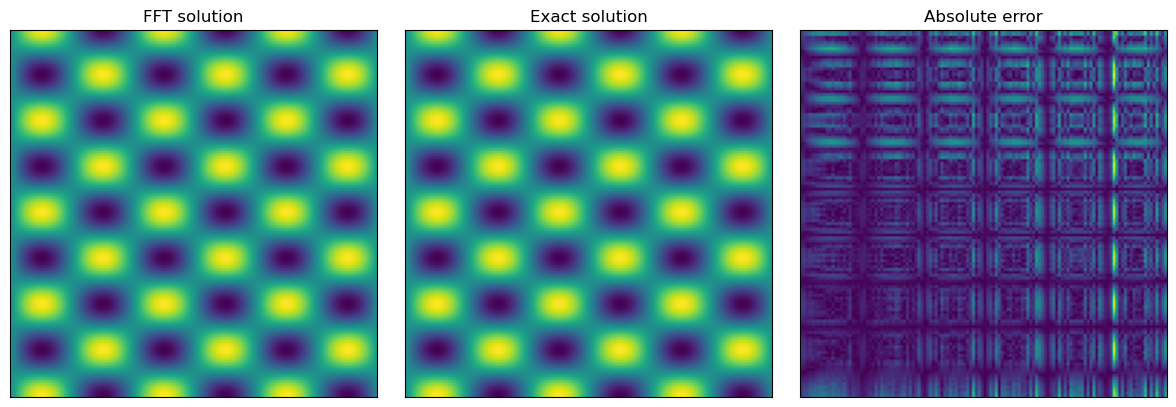

In [13]:
m = 3
ell = 4
t = 0.9

u_mode = np.sin(m * X) * np.cos(ell * Y)
u_fft = heat_solution_fft_2d(u_mode, K2, kappa, t)
u_exact = np.exp(-kappa * (m**2 + ell**2) * t) * np.sin(m * X) * np.cos(ell * Y)

err = np.linalg.norm(u_fft - u_exact) / np.sqrt(nx * ny)
print('RMS error for single-mode test:', err)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(u_fft, origin='lower', extent=[0, Lx, 0, Ly])
axes[0].set_title('FFT solution')
axes[1].imshow(u_exact, origin='lower', extent=[0, Lx, 0, Ly])
axes[1].set_title('Exact solution')
axes[2].imshow(np.abs(u_fft - u_exact), origin='lower', extent=[0, Lx, 0, Ly])
axes[2].set_title('Absolute error')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Final summary

This notebook solved the 2D periodic heat equation by moving to Fourier space.

Key ideas:

- represent the solution in a Fourier basis
- the Laplacian becomes multiplication by $-(k^2+\ell^2)$
- evolve each mode exactly
- use the 2D FFT and inverse FFT to move between physical space and Fourier space efficiently

So instead of solving one big coupled PDE directly, we solved many small scalar ODEs in the right basis.

## Suggested project extensions

- try different initial temperature patterns
- compare against a finite-difference time-stepping solver
- study the effect of changing $\kappa$
- track total energy decay over time
- build a real animation from the snapshot sequence
- extend the same idea to another PDE with Fourier modes
